#Bootstrap and Algebraic Regression

This project phase involves processing the data through different forms of algebraic and bootstrap regression to deduce if there is any correlation between ESG metrics and investment performance

In [19]:
!pip install yahoofinance
!git clone https://github.com/ArmandSDarmosusilo/Quantitative-ESG-Research-Project
!git -C Quantitative-ESG-Research-Project pull
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    max_error
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit

fatal: destination path 'Quantitative-ESG-Research-Project' already exists and is not an empty directory.
Already up to date.


In [20]:
df_model = pd.read_csv("Quantitative-ESG-Research-Project/Data/esg_stock.csv")

print("Full Info:")
display(df_model)

feature_cols = [
    "ENVIRON_DISCLOSURE_SCORE",
    "SOCIAL_DISCLOSURE_SCORE",
    "GOVNCE_DISCLOSURE_SCORE",
]

target_col = "Future_Sharpe"

X_train = df_model[df_model["Year"]<=2022][feature_cols]
Y_train = df_model[df_model["Year"]<=2022][target_col]

X_val = df_model[df_model["Year"]==2023][feature_cols]
Y_val = df_model[df_model["Year"]==2023][target_col]

X_test = df_model[df_model["Year"]==2024][feature_cols]
Y_test = df_model[df_model["Year"]==2024][target_col]

print("\nX_train:")
display(X_train)
print("\nY_train:")
display(Y_train)

print("\nX_val:")
display(X_val)
print("\nY_val:")
display(Y_val)

print("\nX_test:")
display(X_test)
print("\nY_test:")
display(Y_test)

Full Info:


,Unnamed: 0,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731606,1.958864,0.428937
1,1,bbca,2017,46.2428,8.0338,46.9770,83.5942,0.428937,0.185790,1.958864,0.617566,0.200174
2,2,bbca,2018,47.2991,11.2051,46.9770,83.5942,0.200174,0.218881,0.617566,1.562406,0.301435
3,3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301435,0.151327,1.562406,-0.083070,0.033343
4,4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...,...
118,118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,119,jsmr,2021,56.2821,51.0420,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099



X_train:


,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE
0,8.0338,42.0496,83.5942
1,8.0338,46.9770,83.5942
2,11.2051,46.9770,83.5942
3,25.5814,51.6324,89.8555
4,25.5814,51.6324,89.8555
...,...,...,...
116,34.0381,34.0992,83.5942
117,36.0012,35.6711,83.5942
118,33.7964,34.0992,83.5942
119,51.0420,34.0992,83.5942



Y_train:


...

,Future_Sharpe
7,-0.030541
16,-0.245732
24,-1.005398
33,-0.731547
42,-1.142759
50,-0.772055
59,0.119298
68,-1.274899
77,-0.255777
86,0.883301



X_test:


,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE
8,32.4071,57.0738,96.1168
25,36.6657,54.3833,87.3570
34,46.1794,51.0883,96.1168
51,57.0220,48.1258,83.5942
60,49.7131,26.9649,87.3570
69,59.8007,40.0544,87.3570
78,54.9079,48.0048,89.8555
87,46.6324,29.5345,89.8555
96,43.0082,41.2334,89.8555
105,71.3078,48.1258,83.5942



Y_test:


,Future_Sharpe
8,-0.687713
25,-0.217883
34,0.077609
51,-0.348183
60,-1.133328
69,0.719169
78,2.078540
87,-0.504145
96,1.403466
105,0.877591


In [21]:
model = LinearRegression(fit_intercept=True, positive=False)
model.fit(X_train, Y_train)

preds = model.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

Performance:
MSE: 1.0394292255991626
RMSE: 1.0195240191379322
MAE: 0.8660930671544254
Median Absolute Error: 0.8690904122134013
Max Error: 2.0632806167182203
R2: -0.13491512500489322
Explained Variance: -0.11500977347859087


In [22]:
model = Ridge()

param_grid = {
    "alpha": np.logspace(-5, 5, 100),
    "solver": ["svd", "cholesky", "sag"]
}

X_combined = pd.concat([X_train, X_val], axis=0)
Y_combined = pd.concat([Y_train, Y_val], axis=0)

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

ridge_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=pds)
ridge_search.fit(X_combined, Y_combined)

preds = ridge_search.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

Performance:
MSE: 1.028893161377791
RMSE: 1.0143437096851298
MAE: 0.8265965049800499
Median Absolute Error: 0.8434203608107411
Max Error: 2.1848075016013753
R2: -0.12341117808059465
Explained Variance: -0.070958383464931


In [23]:
model = ElasticNet()

param_grid = {
    "alpha": np.logspace(-5, 5, 100),
    "l1_ratio": np.logspace(-5, 0, 100)
}

X_combined = pd.concat([X_train, X_val], axis=0)
Y_combined = pd.concat([Y_train, Y_val], axis=0)

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

elastic_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=pds)
elastic_search.fit(X_combined, Y_combined)

preds = elastic_search.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

Performance:
MSE: 1.0241641179739498
RMSE: 1.0120099396616369
MAE: 0.8252790614735249
Median Absolute Error: 0.7326014452962789
Max Error: 2.1957847902080476
R2: -0.11824770686615937
Explained Variance: -0.06554518158605527


Performance:
MSE: 1.1133325002531091
RMSE: 1.0551457246528126
MAE: 0.8840209394869223
Median Absolute Error: 0.898456052922278
Max Error: 2.1546431570021105
R2: -0.21560743394377924
Explained Variance: -0.18718506564195692

Feature Importance:
                    Feature  Importance
0  ENVIRON_DISCLOSURE_SCORE    0.488427
1   SOCIAL_DISCLOSURE_SCORE    0.398397
2   GOVNCE_DISCLOSURE_SCORE    0.113175

Example Predictions:
    Ticker  Year  Actual_Sharpe  Predicted_Sharpe     Error  Absolute_Error
8     bbca  2024      -0.687713          0.210744 -0.898456        0.898456
25    bbri  2024      -0.217883          0.062739 -0.280622        0.280622
34    bbni  2024       0.077609          0.147213 -0.069603        0.069603
51    klbf  2024      -0.348183         -0.141979 -0.206204        0.206204
60    icbp  2024      -1.133328          0.059501 -1.192829        1.192829
69    unvr  2024       0.719169         -0.463519  1.182688        1.182688
78    antm  2024       2.078540         -0

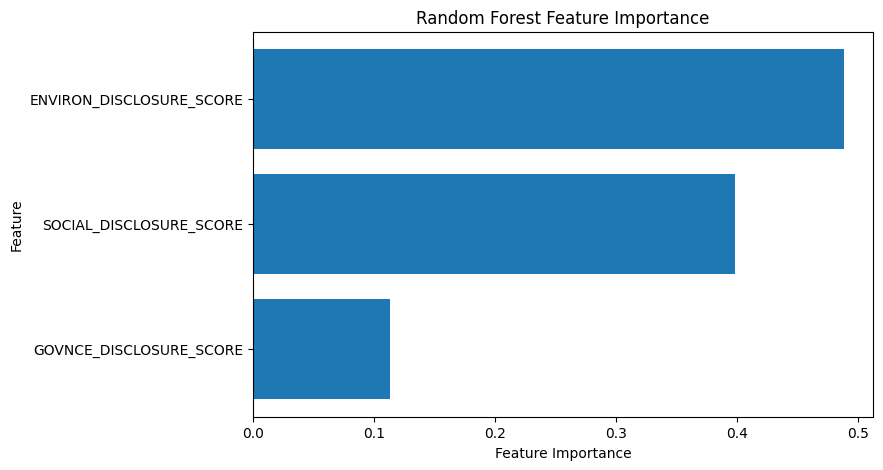

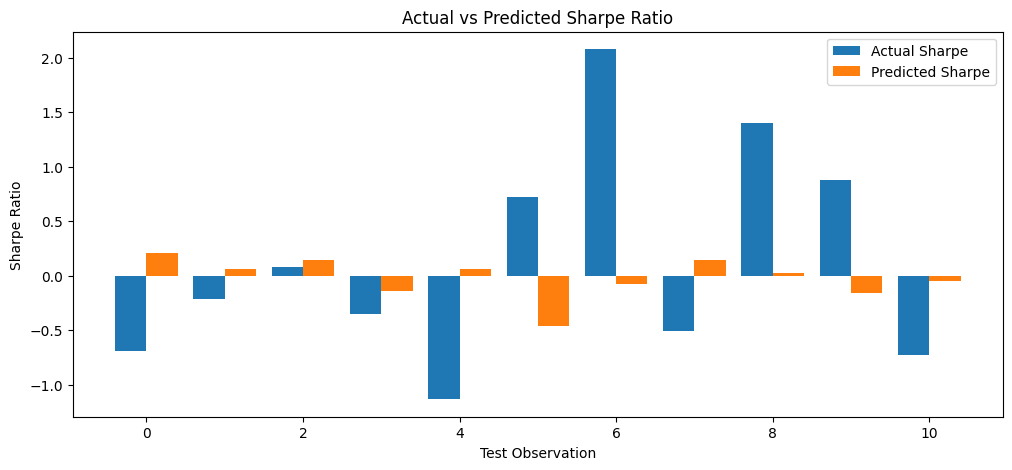

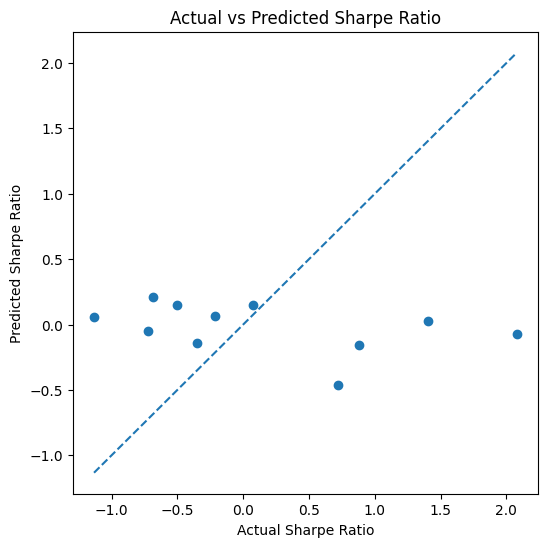

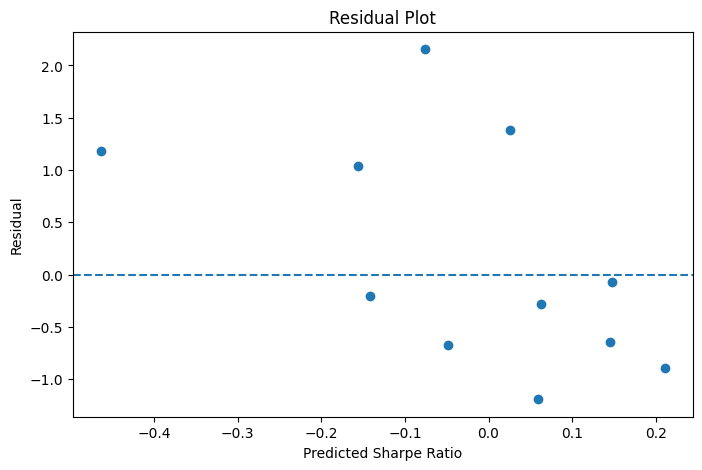


Custom E/S/G Sharpe Prediction:
Environmental Score: 60
Social Score: 50
Governance Score: 80
Predicted Sharpe Ratio: -0.5255861666027686


In [24]:
model = RandomForestRegressor()

param_distributions = {
    "n_estimators": [200, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_leaf": [2, 4, 8, 16, 24, 32, 64],
    "min_samples_split": [4, 8, 16, 24, 32, 64, 128],
    "max_features": ["sqrt", "log2", 0.25, 0.5, 0.75, 1.0]
}

X_combined = pd.concat([X_train, X_val], axis=0)
Y_combined = pd.concat([Y_train, Y_val], axis=0)

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

rforest_search = RandomizedSearchCV(estimator=model, param_distributions=param_distributions, cv=pds, n_iter=25, n_jobs=-1)
rforest_search.fit(X_combined, Y_combined)

preds = rforest_search.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

model.fit(X_train, Y_train)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)

results_df = X_test.copy()

results_df["Actual_Sharpe"] = Y_test.values
results_df["Predicted_Sharpe"] = preds
results_df["Error"] = results_df["Actual_Sharpe"] - results_df["Predicted_Sharpe"]
results_df["Absolute_Error"] = np.abs(results_df["Error"])

if "Ticker" in df_model.columns:
    results_df["Ticker"] = df_model.loc[X_test.index, "Ticker"].values

if "Year" in df_model.columns:
    results_df["Year"] = df_model.loc[X_test.index, "Year"].values

display_cols = []

if "Ticker" in results_df.columns:
    display_cols.append("Ticker")

if "Year" in results_df.columns:
    display_cols.append("Year")

display_cols += [
    "Actual_Sharpe",
    "Predicted_Sharpe",
    "Error",
    "Absolute_Error"
]

results_df = results_df[display_cols]

print("\nExample Predictions:")
print(results_df.head(10))

print("\nBest Predictions:")
print(results_df.sort_values(by="Absolute_Error").head(10))

print("\nWorst Predictions:")
print(results_df.sort_values(by="Absolute_Error", ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

plot_results = results_df.copy().reset_index(drop=True)

plt.figure(figsize=(12, 5))
x_axis = np.arange(len(plot_results))

plt.bar(x_axis - 0.2, plot_results["Actual_Sharpe"], width=0.4, label="Actual Sharpe")
plt.bar(x_axis + 0.2, plot_results["Predicted_Sharpe"], width=0.4, label="Predicted Sharpe")

plt.xlabel("Test Observation")
plt.ylabel("Sharpe Ratio")
plt.title("Actual vs Predicted Sharpe Ratio")
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(Y_test, preds)

min_val = min(Y_test.min(), preds.min())
max_val = max(Y_test.max(), preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Sharpe Ratio")
plt.ylabel("Predicted Sharpe Ratio")
plt.title("Actual vs Predicted Sharpe Ratio")
plt.show()

residuals = Y_test.values - preds

plt.figure(figsize=(8, 5))
plt.scatter(preds, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sharpe Ratio")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

def predict_sharpe(env_score, gov_score, social_score):
    input_data = pd.DataFrame({
        "ENVIRON_DISCLOSURE_SCORE": [env_score],
        "SOCIAL_DISCLOSURE_SCORE": [social_score],
        "GOVNCE_DISCLOSURE_SCORE": [gov_score]
    })

    predicted_sharpe = model.predict(input_data)[0]

    return predicted_sharpe

example_env = 60
example_gov = 80
example_social = 50

example_prediction = predict_sharpe(
    env_score=example_env,
    gov_score=example_gov,
    social_score=example_social
)

print("\nCustom E/S/G Sharpe Prediction:")
print("Environmental Score:", example_env)
print("Social Score:", example_social)
print("Governance Score:", example_gov)
print("Predicted Sharpe Ratio:", example_prediction)

custom_esg_examples = pd.DataFrame({
    "ENVIRON_DISCLOSURE_SCORE": [30, 50, 70, 90],
    "SOCIAL_DISCLOSURE_SCORE": [30, 50, 70, 90],
    "GOVNCE_DISCLOSURE_SCORE": [60, 70, 80, 90],
})


Shap Scores:

Multiple Custom E/S/G Predictions:
   ENVIRON_DISCLOSURE_SCORE  SOCIAL_DISCLOSURE_SCORE  GOVNCE_DISCLOSURE_SCORE  \
0                        30                       30                       60   
1                        50                       50                       70   
2                        70                       70                       80   
3                        90                       90                       90   

   Predicted_Sharpe  
0          0.421630  
1          0.223830  
2         -0.345438  
3         -0.382614  


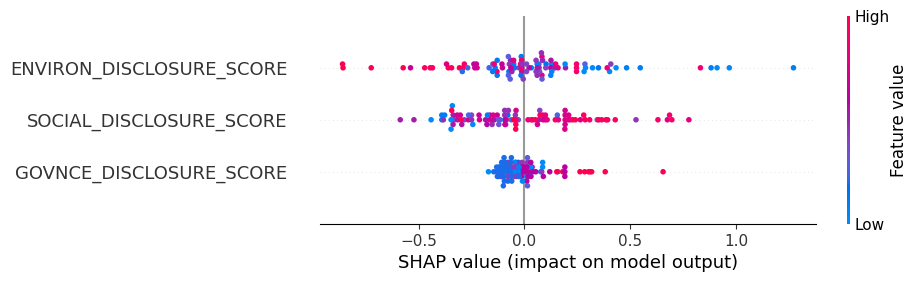

In [25]:
custom_esg_examples["Predicted_Sharpe"] = model.predict(custom_esg_examples)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

print("\nShap Scores:")
shap.plots.beeswarm(shap_values, show=False)

print("\nMultiple Custom E/S/G Predictions:")
print(custom_esg_examples)